# 📊 Análise Exploratória de Dados (EDA)
**Instacart Market Basket Analysis**

Este notebook realiza uma análise exploratória completa da base de dados Instacart, cobrindo:
- Estrutura e qualidade dos dados
- Padrões temporais de pedidos
- Popularidade de produtos, aisles e departamentos
- Taxa de recompra
- Coocorrência entre produtos (prévia de Market Basket)

---

In [1]:
# =========================================
# 📚 IMPORTAÇÃO DAS BIBLIOTECAS
# =========================================

import warnings
from pathlib import Path
from collections import Counter
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

# Estilo visual consistente em todo o notebook
sns.set_theme(style="whitegrid", palette="viridis")
PALETTE = "viridis"
FIG_SIZE = (13, 5)

## 📂 1. Carregamento dos Dados

In [2]:
orders = pd.read_csv("../data/raw/orders.csv")

products = pd.read_csv("../data/raw/products.csv")

order_products_train = pd.read_csv(
    "../data/raw/order_products__train.csv"
)

order_products_prior = pd.read_csv(
    "../data/raw/order_products__prior.csv"
)

aisles = pd.read_csv("../data/raw/aisles.csv")

departments = pd.read_csv("../data/raw/departments.csv")
datasets = {
    "orders": orders,
    "products": products,
    "order_products_train": order_products_train,
    "order_products_prior": order_products_prior,
    "aisles": aisles,
    "departments": departments,
}

print("=" * 50)
print(f"{'Dataset':<30} {'Linhas':>10} {'Colunas':>8}")
print("=" * 50)
for name, df in datasets.items():
    print(f"{name:<30} {df.shape[0]:>10,} {df.shape[1]:>8}")
print("=" * 50)

Dataset                            Linhas  Colunas
orders                          3,421,083        7
products                           49,688        4
order_products_train            1,384,617        4
order_products_prior           32,434,489        4
aisles                                134        2
departments                            21        2


### 🔍 Valores Nulos
Verificamos a presença de valores ausentes em cada tabela antes de qualquer análise.

In [3]:
for name, df in datasets.items():
    nulls = df.isnull().sum()
    if nulls.any():
        print(f"\n📌 {name}")
        print(nulls[nulls > 0].to_string())
    else:
        print(f"✅ {name}: sem valores nulos")


📌 orders
days_since_prior_order    206209
✅ products: sem valores nulos
✅ order_products_train: sem valores nulos
✅ order_products_prior: sem valores nulos
✅ aisles: sem valores nulos
✅ departments: sem valores nulos


---
## ⏰ 2. Padrões Temporais de Pedidos

Analisamos como os pedidos se distribuem ao longo das horas do dia e dos dias da semana,
identificando os horários de pico de uso da plataforma.

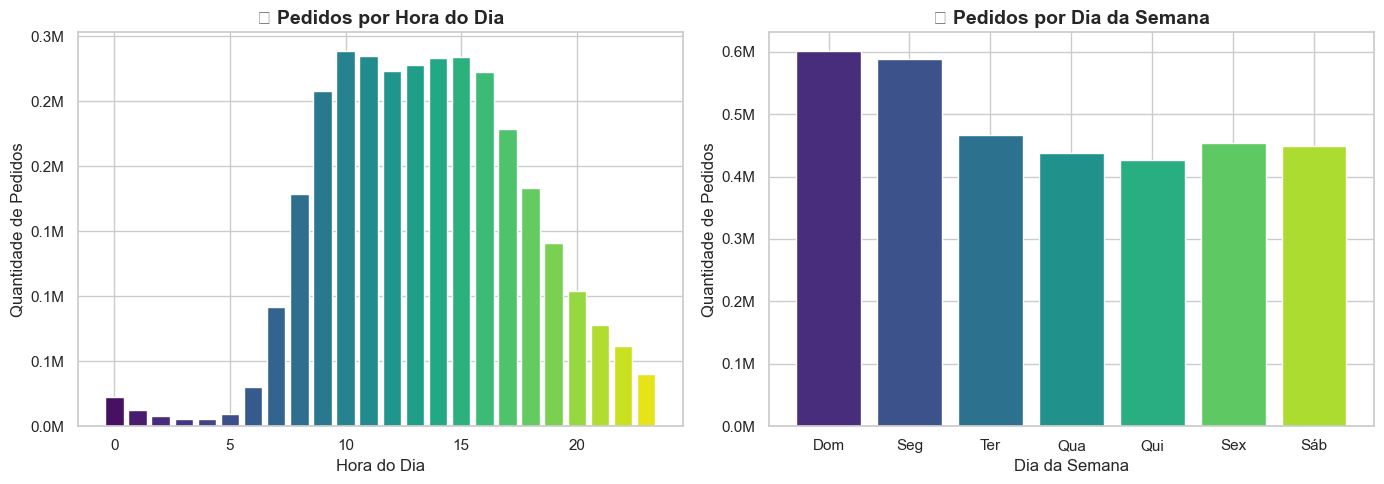

⏰ Hora de pico: 10h (288,418 pedidos)
📅 Dia mais movimentado: Dom (600,905 pedidos)


In [4]:
day_map = {0: "Dom", 1: "Seg", 2: "Ter", 3: "Qua", 4: "Qui", 5: "Sex", 6: "Sáb"}
orders["dow_label"] = orders["order_dow"].map(day_map)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pedidos por hora
hour_counts = orders["order_hour_of_day"].value_counts().sort_index()
axes[0].bar(hour_counts.index, hour_counts.values,
            color=sns.color_palette("viridis", len(hour_counts)))
axes[0].set_title("📊 Pedidos por Hora do Dia", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Hora do Dia")
axes[0].set_ylabel("Quantidade de Pedidos")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

# Pedidos por dia da semana
dow_counts = orders.groupby("order_dow")["order_id"].count()
colors_dow = sns.color_palette("viridis", 7)
axes[1].bar([day_map[i] for i in dow_counts.index], dow_counts.values, color=colors_dow)
axes[1].set_title("📅 Pedidos por Dia da Semana", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Dia da Semana")
axes[1].set_ylabel("Quantidade de Pedidos")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

plt.tight_layout()
plt.show()

print(f"⏰ Hora de pico: {hour_counts.idxmax()}h ({hour_counts.max():,.0f} pedidos)")
print(f"📅 Dia mais movimentado: {day_map[dow_counts.idxmax()]} ({dow_counts.max():,.0f} pedidos)")

---
## 🔁 3. Taxa de Recompra e Intervalo entre Pedidos

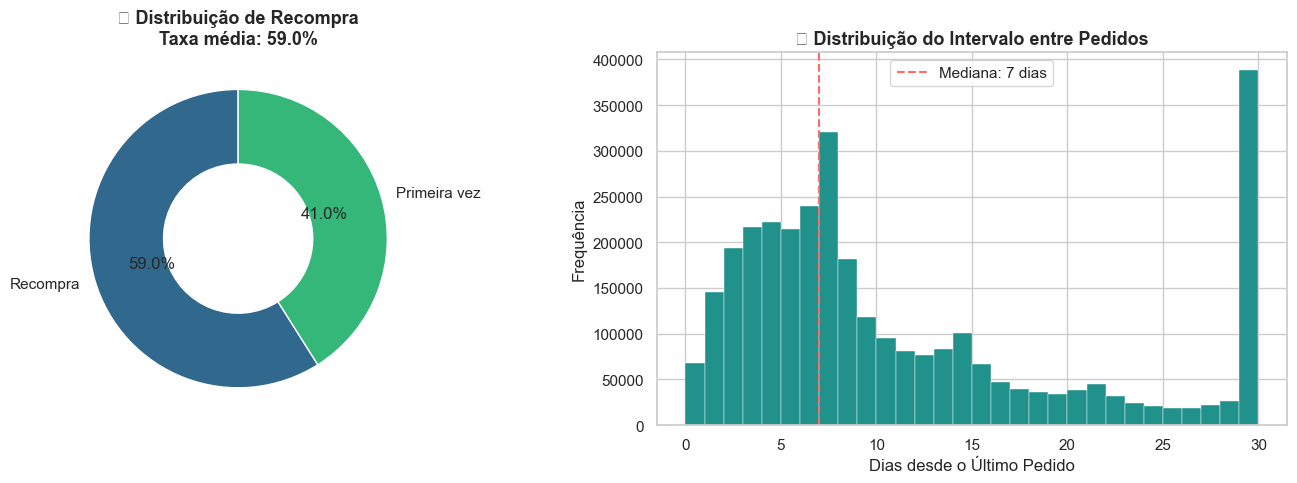

📊 Média de dias entre pedidos: 11.1
📊 Mediana: 7 dias


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribuição de recompra
reorder_rate = order_products_prior["reordered"].mean()

reorder_counts = (
    order_products_prior["reordered"]
    .value_counts()
    .reindex([1, 0])
)

wedge_props = dict(width=0.5)

axes[0].pie(
    reorder_counts.values,
    labels=["Recompra", "Primeira vez"],
    autopct="%1.1f%%",
    colors=sns.color_palette("viridis", 2),
    wedgeprops=wedge_props,
    startangle=90,
)

axes[0].set_title(
    f"🔁 Distribuição de Recompra\nTaxa média: {reorder_rate:.1%}",
    fontsize=13,
    fontweight="bold"
)

# Intervalo entre pedidos
days_data = orders["days_since_prior_order"].dropna()

axes[1].hist(
    days_data,
    bins=30,
    color=sns.color_palette("viridis", 1)[0],
    edgecolor="white",
    linewidth=0.3
)

axes[1].set_title(
    "⏳ Distribuição do Intervalo entre Pedidos",
    fontsize=13,
    fontweight="bold"
)
axes[1].set_xlabel("Dias desde o Último Pedido")
axes[1].set_ylabel("Frequência")

axes[1].axvline(
    days_data.median(),
    color="#ff6b6b",
    linestyle="--",
    label=f"Mediana: {days_data.median():.0f} dias"
)

axes[1].legend()

plt.tight_layout()
plt.show()

print(f"📊 Média de dias entre pedidos: {days_data.mean():.1f}")
print(f"📊 Mediana: {days_data.median():.0f} dias")

---
## 🛒 4. Popularidade de Produtos, Aisles e Departamentos

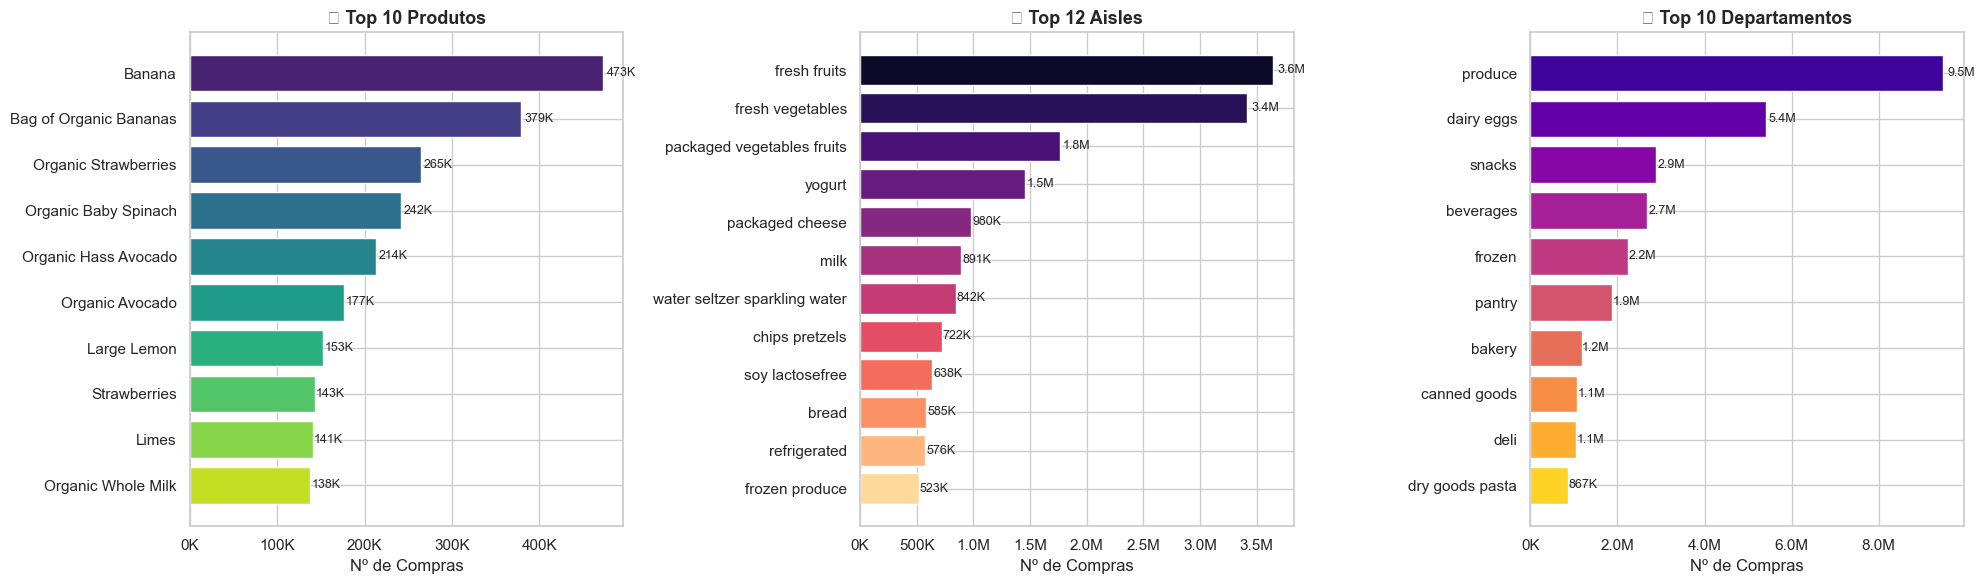

In [6]:
# Enriquece produtos com aisle e department
products_enriched = (
    products
    .merge(aisles, on="aisle_id", how="left")
    .merge(departments, on="department_id", how="left")
)

# Junta histórico de compras com produtos
opp_enriched = order_products_prior.merge(
    products_enriched[["product_id", "product_name", "aisle", "department"]],
    on="product_id"
)

# Top 10 produtos
top_products = (
    opp_enriched.groupby("product_name")["order_id"]
    .count()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name="compras")
)

# Top 12 aisles
top_aisles = (
    opp_enriched.groupby("aisle")["order_id"]
    .count()
    .sort_values(ascending=False)
    .head(12)
    .reset_index(name="compras")
)

# Top 10 departamentos
top_departments = (
    opp_enriched.groupby("department")["order_id"]
    .count()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name="compras")
)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

def h_bar(ax, df, col_label, col_val, title, color_palette="viridis"):
    colors = sns.color_palette(color_palette, len(df))[::-1]
    ax.barh(df[col_label][::-1], df[col_val][::-1], color=colors)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Nº de Compras")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{x/1e3:.0f}K"))
    for bar in ax.patches:
        w = bar.get_width()
        label = f"{w/1e6:.1f}M" if w >= 1e6 else f"{w/1e3:.0f}K"
        ax.text(w * 1.01, bar.get_y() + bar.get_height()/2, label, va="center", fontsize=9)

h_bar(axes[0], top_products, "product_name", "compras", "🏆 Top 10 Produtos")
h_bar(axes[1], top_aisles, "aisle", "compras", "🛒 Top 12 Aisles", "magma")
h_bar(axes[2], top_departments, "department", "compras", "🏬 Top 10 Departamentos", "plasma")

plt.tight_layout()
plt.show()

---
## 📦 5. Tamanho dos Carrinhos e Usuários Mais Ativos

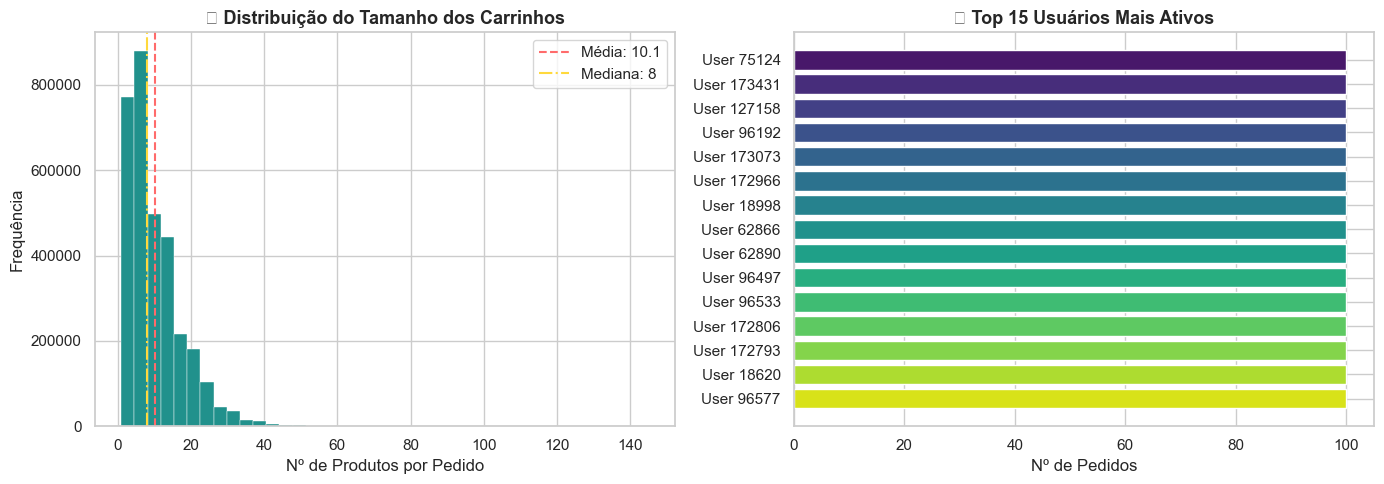

🧺 Média de itens por pedido: 10.09
🧺 Mediana: 8
🧺 Máximo: 145


In [9]:
cart_size = order_products_prior.groupby("order_id").size()

top_users = (
    orders["user_id"]
    .value_counts()
    .head(15)
    .reset_index()
)

top_users.columns = ["user_id", "pedidos"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribuição do tamanho dos carrinhos
axes[0].hist(
    cart_size,
    bins=40,
    color=sns.color_palette("viridis", 1)[0],
    edgecolor="white",
    linewidth=0.3
)

axes[0].axvline(
    cart_size.mean(),
    color="#ff6b6b",
    linestyle="--",
    label=f"Média: {cart_size.mean():.1f}"
)

axes[0].axvline(
    cart_size.median(),
    color="#ffd93d",
    linestyle="-.",
    label=f"Mediana: {cart_size.median():.0f}"
)

axes[0].set_title(
    "🧺 Distribuição do Tamanho dos Carrinhos",
    fontsize=13,
    fontweight="bold"
)

axes[0].set_xlabel("Nº de Produtos por Pedido")
axes[0].set_ylabel("Frequência")
axes[0].legend()

# Usuários mais ativos
colors_u = sns.color_palette("viridis", len(top_users))

axes[1].barh(
    [f"User {uid}" for uid in top_users["user_id"][::-1]],
    top_users["pedidos"][::-1],
    color=colors_u[::-1]
)

axes[1].set_title(
    "👤 Top 15 Usuários Mais Ativos",
    fontsize=13,
    fontweight="bold"
)

axes[1].set_xlabel("Nº de Pedidos")

plt.tight_layout()
plt.show()

print(f"🧺 Média de itens por pedido: {cart_size.mean():.2f}")
print(f"🧺 Mediana: {cart_size.median():.0f}")
print(f"🧺 Máximo: {cart_size.max()}")

---
## 🔁 6. Produtos com Maior Taxa de Recompra

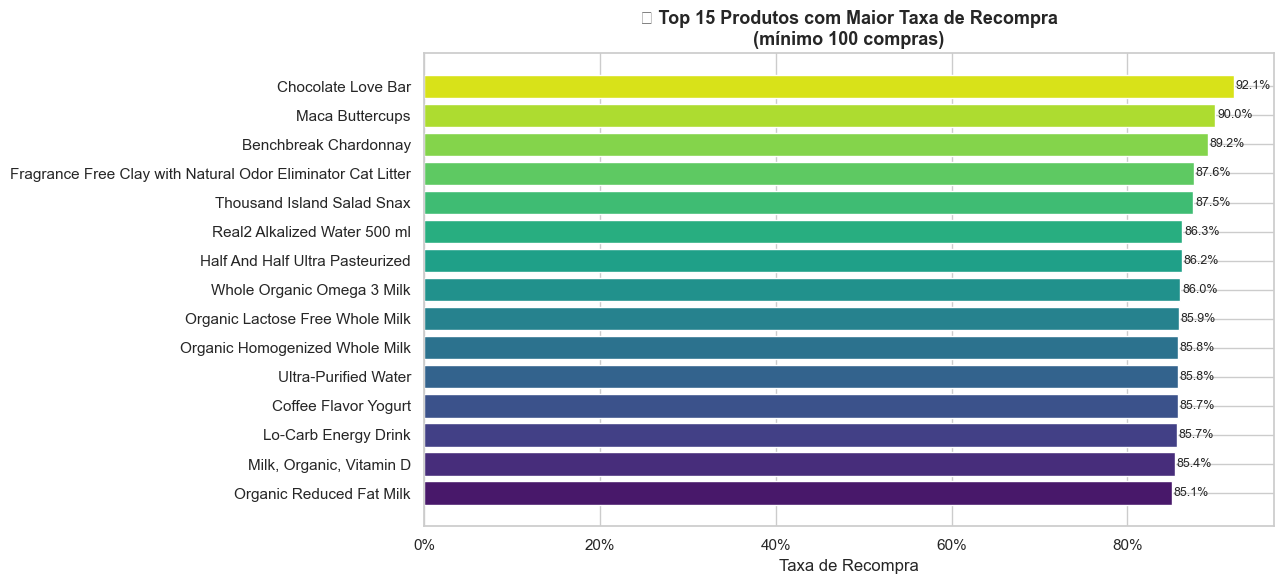

In [10]:
# Filtra produtos com mínimo de compras para evitar ruído
MIN_PURCHASES = 100

product_reorder = (
    order_products_prior
    .groupby("product_id")
    .agg(
        total_purchases=("reordered", "count"),
        reorder_rate=("reordered", "mean")
    )
    .reset_index()
)

product_reorder_filtered = product_reorder[
    product_reorder["total_purchases"] >= MIN_PURCHASES
].merge(products[["product_id", "product_name"]], on="product_id")

top_reordered = (
    product_reorder_filtered
    .sort_values("reorder_rate", ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(13, 6))
colors = sns.color_palette("viridis", len(top_reordered))
ax.barh(top_reordered["product_name"][::-1],
        top_reordered["reorder_rate"][::-1],
        color=colors)
ax.set_xlabel("Taxa de Recompra")
ax.set_title(f"🔁 Top 15 Produtos com Maior Taxa de Recompra\n(mínimo {MIN_PURCHASES} compras)",
             fontsize=13, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
for bar in ax.patches:
    w = bar.get_width()
    ax.text(w + 0.002, bar.get_y() + bar.get_height()/2,
            f"{w:.1%}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

---
## 🔗 7. Top Pares de Produtos Comprados Juntos

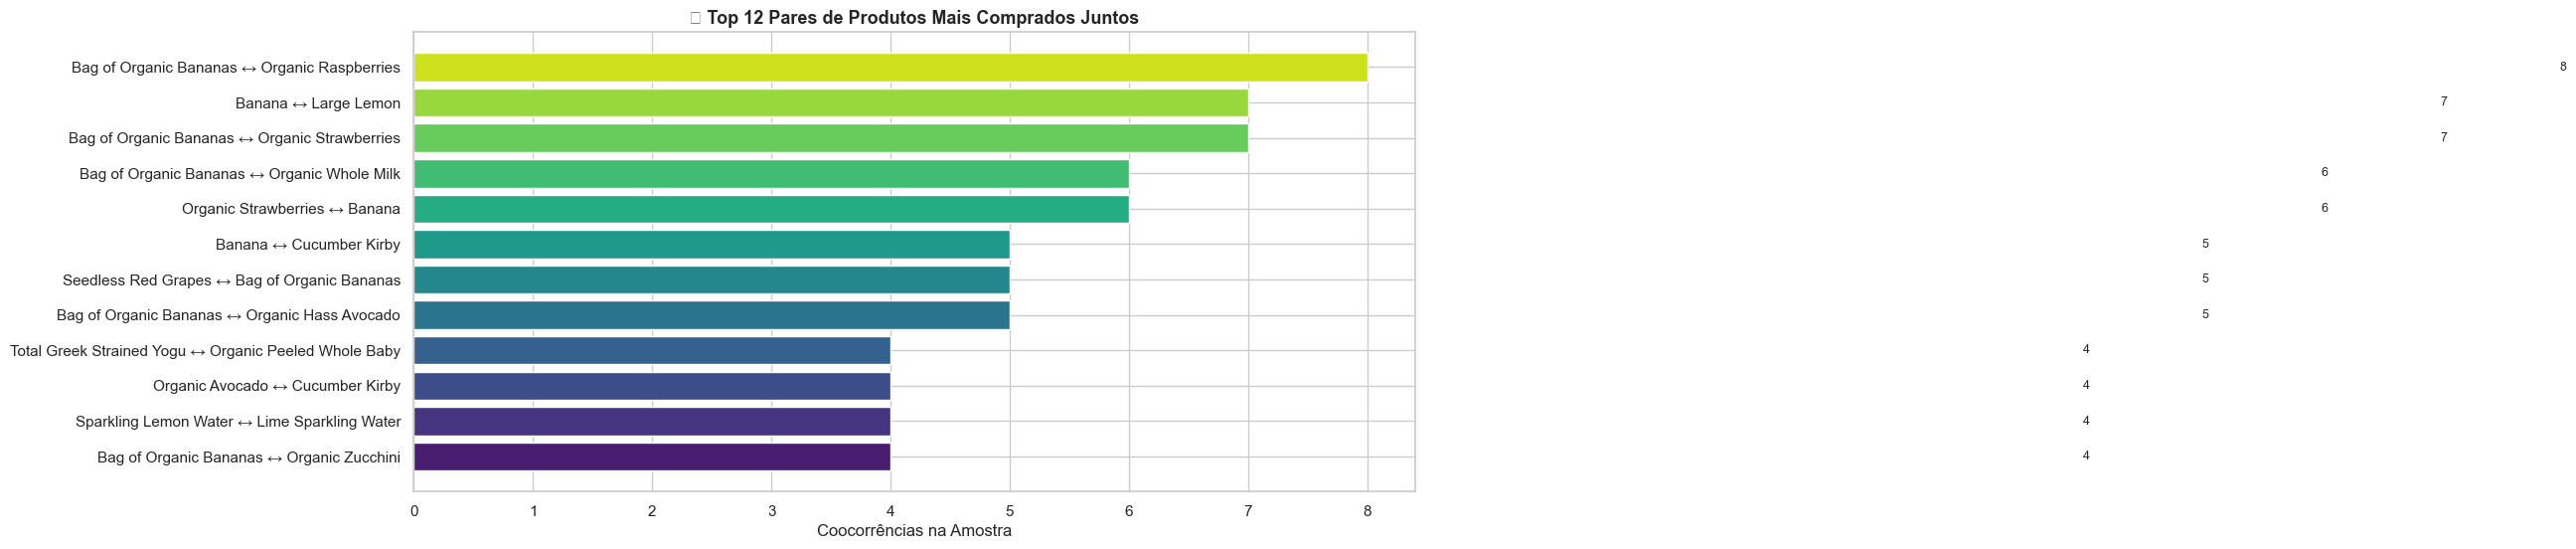

In [11]:
N_SAMPLE = 300_000
RANDOM_STATE = 42

sample = order_products_prior.sample(n=N_SAMPLE, random_state=RANDOM_STATE)
baskets = sample.groupby("order_id")["product_id"].apply(lambda x: list(set(x)))

pair_counter = Counter()
for lst in baskets:
    if len(lst) > 1:
        for pair in combinations(sorted(lst), 2):
            pair_counter[pair] += 1

product_map = dict(zip(products["product_id"], products["product_name"]))

top_pairs_df = pd.DataFrame(
    pair_counter.most_common(12),
    columns=["pair", "cooccurrence"]
)
top_pairs_df["product_1"] = top_pairs_df["pair"].apply(lambda x: product_map.get(x[0], x[0]))
top_pairs_df["product_2"] = top_pairs_df["pair"].apply(lambda x: product_map.get(x[1], x[1]))
top_pairs_df["label"] = top_pairs_df["product_1"].str[:25] + " ↔ " + top_pairs_df["product_2"].str[:25]

fig, ax = plt.subplots(figsize=(13, 6))
colors = sns.color_palette("viridis", len(top_pairs_df))
ax.barh(top_pairs_df["label"][::-1], top_pairs_df["cooccurrence"][::-1], color=colors)
ax.set_xlabel("Coocorrências na Amostra")
ax.set_title("🔗 Top 12 Pares de Produtos Mais Comprados Juntos", fontsize=13, fontweight="bold")
for bar in ax.patches:
    w = bar.get_width()
    ax.text(w + 10, bar.get_y() + bar.get_height()/2, f"{w:,.0f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

---
## 📌 Conclusão do EDA

| Insight | Detalhe |
|---|---|
| Volume de dados | ~3.4M pedidos, 32M+ interações no histórico prior |
| Pico de compras | Horário comercial (9h–16h), maior volume no Domingo e Segunda |
| Taxa de recompra | ~59% das compras são recompras — comportamento fortemente recorrente |
| Categorias líderes | `produce`, `dairy eggs` e `snacks` dominam o volume |
| Tamanho médio do carrinho | ~10 itens por pedido |
| Pares mais comuns | Bananas orgânicas + Morangos orgânicos / Framboesas |

Estes insights guiam as próximas etapas: construção de features, análise de cesta, similaridade e embeddings.
